# Task 2: Exploratory Data Analysis (EDA)

## Data Loading and Overview

In [1]:
import pandas as pd

df = pd.read_csv("Video_Games_Sales_Cleaned.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540americafrontccc.jpg,grand theft auto v,ps3,action,rockstar games,rockstar north,9.40000,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178americafrontccc.jpg,grand theft auto v,ps4,action,rockstar games,rockstar north,9.70000,19.39,6.06,0.60,9.71,3.02,18-11-2014,01-03-2018
2,/games/boxart/827563ccc.jpg,grand theft auto: vice city,ps2,action,rockstar games,rockstar north,9.60000,16.15,8.41,0.47,5.49,1.78,28-10-2002,01-03-2018
3,/games/boxart/full_9218923americafrontccc.jpg,grand theft auto v,x360,action,rockstar games,rockstar north,7.22044,15.86,9.06,0.06,5.33,1.42,17-09-2013,01-03-2018
4,/games/boxart/full_4990510americafrontccc.jpg,call of duty: black ops 3,ps4,shooter,activision,treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,06-11-2015,01-03-2018


## Data Understanding

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     64016 non-null  object 
 6   critic_score  64016 non-null  float64
 7   total_sales   64016 non-null  float64
 8   na_sales      64016 non-null  float64
 9   jp_sales      64016 non-null  float64
 10  pal_sales     64016 non-null  float64
 11  other_sales   64016 non-null  float64
 12  release_date  64016 non-null  object 
 13  last_update   64015 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


## Basic Analysis

In [3]:
df['total_sales'].mean()
df['genre'].value_counts().head()

genre
misc            9304
action          8557
adventure       6260
role-playing    5721
sports          5586
Name: count, dtype: int64

## Top Games by Sales

In [4]:
df.sort_values(by='total_sales', ascending=False).head(10)[['title','total_sales']]

,title,total_sales
0,grand theft auto v,20.32
1,grand theft auto v,19.39
2,grand theft auto: vice city,16.15
3,grand theft auto v,15.86
4,call of duty: black ops 3,15.09
5,call of duty: modern warfare 3,14.82
6,call of duty: black ops,14.74
7,red dead redemption 2,13.94
8,call of duty: black ops ii,13.86
9,call of duty: black ops ii,13.80


## Sales by Genre

In [5]:
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales

genre
sports              1187.51
action              1125.89
shooter              995.50
misc                 557.79
racing               525.75
role-playing         426.80
platform             349.15
fighting             341.13
adventure            325.39
simulation           300.65
action-adventure     148.52
puzzle               127.28
strategy             118.31
music                 51.75
mmo                    9.31
party                  6.21
visual novel           5.78
sandbox                1.89
education              0.97
board game             0.33
Name: total_sales, dtype: float64

## Sales by Platform

In [6]:
platform_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10)
platform_sales

console
ps2     1027.76
x360     859.79
ps3      839.70
ps       546.25
ps4      539.92
wii      459.44
ds       458.17
xone     268.96
psp      245.29
xb       232.05
Name: total_sales, dtype: float64

## Data Visualization

### Top Genres by Sales

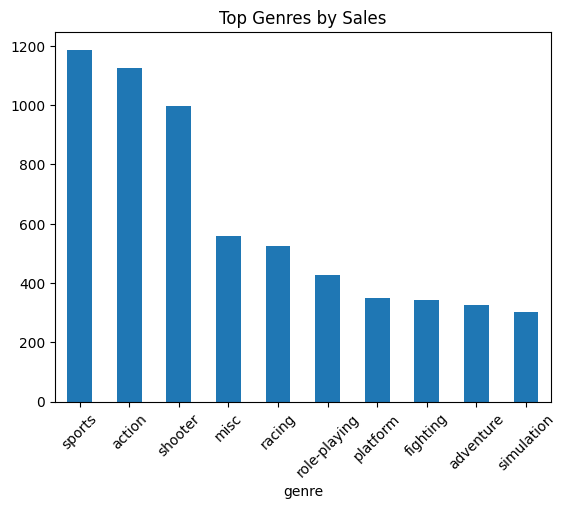

In [7]:
import matplotlib.pyplot as plt

genre_sales.head(10).plot(kind='bar')
plt.title("Top Genres by Sales")
plt.xticks(rotation=45)
plt.show()

### Sales Distribution

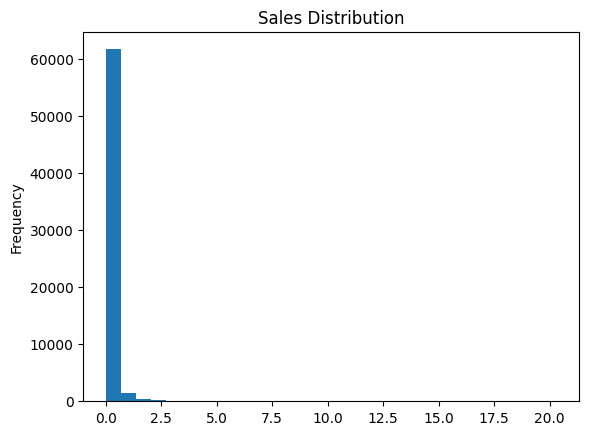

In [8]:
df['total_sales'].plot(kind='hist', bins=30)
plt.title("Sales Distribution")
plt.show()

# Top Platforms by Sales

<Axes: title={'center': 'Top Platforms by Sales'}, xlabel='console'>

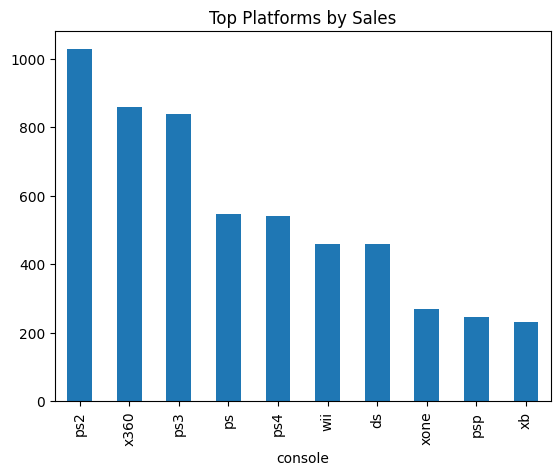

In [10]:
df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar', title="Top Platforms by Sales")

### Critic Score vs Sales

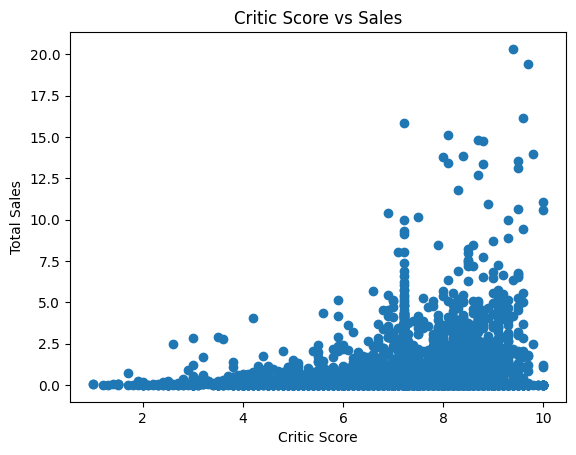

In [11]:
plt.scatter(df['critic_score'], df['total_sales'])
plt.xlabel("Critic Score")
plt.ylabel("Total Sales")
plt.title("Critic Score vs Sales")
plt.show()

## Key Insights

- Sports is the top-selling genre  
- PS2 is the highest-selling platform  
- Most games have low sales  
- No strong correlation between critic score and sales  
- Game releases increased over time